<a href="https://colab.research.google.com/github/konchadakushal/kushalrepo/blob/main/EDAproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/housing_prices_regression.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_bedrooms   238 non-null    float64
 1   year_built     241 non-null    float64
 2   zipcode_dup    230 non-null    float64
 3   zipcode        230 non-null    float64
 4   size_sqft      237 non-null    object 
 5   has_garage     237 non-null    object 
 6   id             230 non-null    object 
 7   has_garden     232 non-null    object 
 8   num_bathrooms  221 non-null    float64
 9   sale_price     238 non-null    float64
dtypes: float64(6), object(4)
memory usage: 20.4+ KB


In [17]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_bedrooms   250 non-null    float64
 1   year_built     250 non-null    float64
 2   zipcode_dup    250 non-null    float64
 3   zipcode        250 non-null    float64
 4   size_sqft      250 non-null    object 
 5   has_garage     250 non-null    object 
 6   id             250 non-null    object 
 7   has_garden     250 non-null    object 
 8   num_bathrooms  250 non-null    float64
 9   sale_price     250 non-null    float64
dtypes: float64(6), object(4)
memory usage: 21.5+ KB


In [11]:
df.isnull().sum()

,0
num_bedrooms,22
year_built,19
zipcode_dup,29
zipcode,29
size_sqft,23
has_garage,23
id,29
has_garden,26
num_bathrooms,37
sale_price,21


In [12]:
df['num_bedrooms'].fillna(df['num_bedrooms'].mean(), inplace=True)
df['year_built'].fillna(df['year_built'].median(), inplace=True)
df['zipcode_dup'].fillna(df['zipcode_dup'].mean(), inplace=True)
df['zipcode'].fillna(df['zipcode'].mean(), inplace=True)
df['num_bathrooms'].fillna(df['num_bathrooms'].mean(), inplace=True)
df['sale_price'].fillna(df['sale_price'].mean(), inplace=True)


/tmp/ipython-input-493507699.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['num_bedrooms'].fillna(df['num_bedrooms'].mean(), inplace=True)
/tmp/ipython-input-493507699.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [13]:
df['size_sqft'].fillna(df['size_sqft'].mode()[0], inplace=True)
df['has_garage'].fillna(df['has_garage'].mode()[0], inplace=True)
df['id'].fillna(df['id'].mode()[0], inplace=True)
df['has_garden'].fillna(df['has_garden'].mode()[0], inplace=True)

/tmp/ipython-input-100607301.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size_sqft'].fillna(df['size_sqft'].mode()[0], inplace=True)
/tmp/ipython-input-100607301.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [14]:
df.isnull().sum()

,0
num_bedrooms,0
year_built,0
zipcode_dup,0
zipcode,0
size_sqft,0
has_garage,0
id,0
has_garden,0
num_bathrooms,0
sale_price,0


In [20]:
df.head(100)

,num_bedrooms,year_built,zipcode_dup,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
0,2.000000,2021.0,110002.000000,110002.000000,1075,Ys,H20000,No,3.000000,427304.847118
1,3.000000,1954.0,560001.000000,560001.000000,1482,Ye,H20001,o,1.500000,293483.530000
2,2.000000,1991.0,560002.000000,560002.000000,1689,No,H20002,No,2.500000,179736.910000
3,3.000000,1956.0,276970.135747,276970.135747,1415,Yes,H20003,es,2.077465,462700.040000
4,2.982456,1991.0,560001.000000,560001.000000,1765,No,H20004,NO,1.000000,272214.400000
...,...,...,...,...,...,...,...,...,...,...
95,2.982456,1967.0,110003.000000,110003.000000,unknown,YES,H20095,No,3.000000,260421.280000
96,1.000000,1971.0,110002.000000,110002.000000,1033,YES,H20096,No,3.000000,606041.360000
97,4.000000,2015.0,110001.000000,110001.000000,1708,No,H20000,es,1.000000,190373.810000
98,2.000000,1970.0,110003.000000,110003.000000,unknown,No,H20098,No,2.500000,188019.470000


In [42]:
df['has_garage'] = df['has_garage'].astype(str).str.lower()
df['has_garden'] = df['has_garden'].astype(str).str.lower()

In [43]:
df['has_garage'] = df['has_garage'].replace({
      'y': 'yes', 'ye': 'yes', 'yes': 'yes', 'es':'yes','ys':'yes',
    'n': 'no', 'no': 'no', 'non': 'no','o':'no'
})

df['has_garden'] = df['has_garden'].replace({
    'y': 'yes', 'ye': 'yes', 'yes': 'yes', 'es':'yes','ys':'yes',
    'n': 'no', 'no': 'no', 'non': 'no','o':'no'
})

In [44]:
df.tail(15)

,num_bedrooms,year_built,zipcode_dup,zipcode,size_sqft,has_garage,id,has_garden,num_bathrooms,sale_price
235,3.0,1976.0,110003.0,110003.0,1156,no,H20000,yes,2.500000,602573.94
236,2.0,1989.0,110001.0,110001.0,1418,no,H20236,no,3.000000,607709.31
237,3.0,1975.0,110002.0,110002.0,1804,yes,H20237,no,2.077465,274312.52
238,3.0,1976.0,560002.0,560002.0,1428,no,H20238,no,1.000000,402459.65
239,2.0,2011.0,560001.0,560001.0,1565,no,H20239,no,2.077465,256844.57
240,4.0,1999.0,110003.0,110003.0,unknown,no,H20240,yes,1.000000,229202.90
241,1.0,1991.0,560002.0,560002.0,1667,no,H20241,no,2.000000,49939.97
242,4.0,1978.0,560002.0,560002.0,1723,no,H20242,yes,3.000000,249613.04
243,3.0,1990.0,110002.0,110002.0,unknown,yes,H20243,yes,1.500000,456556.86
244,2.0,2009.0,110001.0,110001.0,1135,no,H20000,no,3.000000,31232.91


In [60]:
df['has_garage'].value_counts()

,count
has_garage,
no,142
yes,108


In [59]:
df['has_garden'].value_counts()

,count
has_garden,
no,145
yes,105


In [47]:
df['num_bedrooms'].unique()

array([2.        , 3.        , 2.98245614, 5.        , 4.        ,
       1.        ])

In [48]:

df['year_built'].unique()

array([2021., 1954., 1991., 1956., 1985., 1976., 2007., 1995., 2015.,
       1974., 1950., 2001., 2003., 2016., 1955., 2019., 2002., 1990.,
       1951., 1971., 1986., 1969., 1973., 2014., 2004., 2013., 1994.,
       1975., 1984., 1977., 1965., 2008., 1964., 1960., 2017., 1992.,
       2018., 1962., 1959., 1999., 2020., 1988., 1952., 1998., 1982.,
       1997., 1981., 2009., 2005., 1979., 1967., 1970., 1993., 1996.,
       1978., 1966., 1980., 1963., 2000., 1953., 1961., 1958., 2011.,
       2006., 1957., 2010., 1983., 1968., 1989., 1972.])

In [49]:
df['zipcode_dup'].unique()

array([110002.        , 560001.        , 560002.        , 276970.13574661,
       110001.        , 110003.        ])

In [50]:
df['zipcode'].unique()

array([110002.        , 560001.        , 560002.        , 276970.13574661,
       110001.        , 110003.        ])

In [51]:
df['size_sqft'].unique()

array(['1075', '1482', '1689', '1415', '1765', '1177', '1901', '1549',
       '2118', '2466', '1312', '1328', '1402', '1738', '2030', '1239',
       '1652', '1446', '1747', '2104', '1404', '832', '1798', '1167',
       'unknown', '1815', '1619', '1459', '1270', '340', '1779', '1399',
       '2105', '1284', '1927', '1960', '1412', '1977', '1278', '1729',
       '1749', '1367', '1937', '1450', '1272', '2276', '1203', '2017',
       '1046', '1695', '2148', '1238', '1128', '1453', '2166', '1146',
       '465', '1524', '1880', '1094', '1839', '1086', '1441', '1801',
       '1573', '1986', '1690', '1212', '2107', '1763', '756', '1846',
       '1271', '1579', '1903', '1280', '842', '2102', '1966', '1465',
       '1841', '1352', '1539', '1442', '1368', '1644', '1017', '1626',
       '1033', '1708', '749', '1852', '1735', '1466', '1633', '1568',
       '824', '1577', '1353', '1218', '2494', '2001', '1040', '2083',
       '902', '1531', '1550', '990', '1946', '2103', '1400', '2501',
       '935'

In [52]:
df['has_garage'].unique()

array(['yes', 'no'], dtype=object)

In [53]:
df['id'].unique()

array(['H20000', 'H20001', 'H20002', 'H20003', 'H20004', 'H20005',
       'H20006', 'H20007', 'H20008', 'H20009', 'H20010', 'H20011',
       'H20012', 'H20013', 'H20014', 'H20016', 'H20017', 'H20018',
       'H20019', 'H20021', 'H20022', 'H20024', 'H20025', 'H20026',
       'H20027', 'H20028', 'H20029', 'H20030', 'H20031', 'H20032',
       'H20033', 'H20034', 'H20035', 'H20036', 'H20037', 'H20038',
       'H20040', 'H20041', 'H20042', 'H20044', 'H20045', 'H20046',
       'H20047', 'H20048', 'H20050', 'H20051', 'H20052', 'H20053',
       'H20054', 'H20055', 'H20056', 'H20057', 'H20058', 'H20059',
       'H20060', 'H20062', 'H20063', 'H20064', 'H20065', 'H20066',
       'H20068', 'H20069', 'H20070', 'H20072', 'H20073', 'H20074',
       'H20075', 'H20076', 'H20077', 'H20078', 'H20079', 'H20080',
       'H20081', 'H20082', 'H20083', 'H20084', 'H20085', 'H20086',
       'H20087', 'H20088', 'H20089', 'H20091', 'H20092', 'H20093',
       'H20094', 'H20095', 'H20096', 'H20098', 'H20099', 'H201

In [54]:
df['has_garden'].unique()

array(['no', 'yes'], dtype=object)

In [55]:
df['num_bathrooms'].unique()

array([3.        , 1.5       , 2.5       , 2.07746479, 1.        ,
       2.        ])

In [56]:

df['sale_price'].unique()


array([427304.8471179, 293483.53     , 179736.91     , 462700.04     ,
       272214.4      ,  94965.59     , 557454.69     , 307194.16     ,
        89077.02     , 358249.24     , 370598.3      , 272870.62     ,
       555601.45     , 701046.18     , 783768.06     , 327503.47     ,
       235789.19     , 354563.61     , 102686.06     , 126793.55     ,
       349114.22     , 617082.28     , 723240.42     , 541909.85     ,
       111019.06     , 547455.22     , 519279.5      , 650438.22     ,
       665441.47     , 348881.27     , 567355.58     , 236552.78     ,
       799488.94     , 165007.37     ,  37788.11     , 627421.66     ,
       374023.43     , 374575.19     , 765367.65     , 738118.88     ,
       269619.95     , 190974.76     , 683331.3      , 727634.68     ,
       447029.63     , 514656.26     , 227824.       , 646618.07     ,
       516734.27     ,  76283.59     , 735269.92     , 503897.59     ,
       178372.14     , 496917.31     , 551646.78     , 434843.16     ,
      

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_bedrooms   250 non-null    float64
 1   year_built     250 non-null    float64
 2   zipcode_dup    250 non-null    float64
 3   zipcode        250 non-null    float64
 4   size_sqft      250 non-null    object 
 5   has_garage     250 non-null    object 
 6   id             250 non-null    object 
 7   has_garden     250 non-null    object 
 8   num_bathrooms  250 non-null    float64
 9   sale_price     250 non-null    float64
dtypes: float64(6), object(4)
memory usage: 21.5+ KB


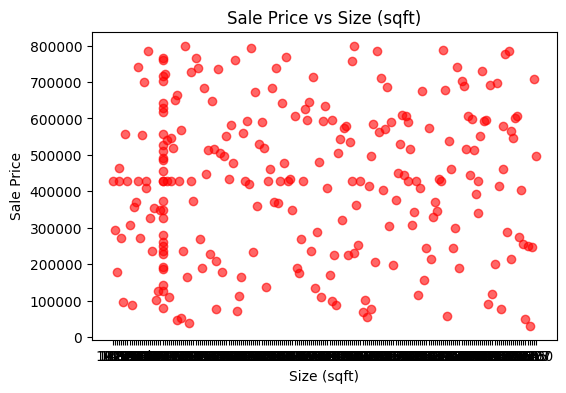

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(df['size_sqft'], df['sale_price'], color='red', alpha=0.6)
plt.title('Sale Price vs Size (sqft)')
plt.xlabel('Size (sqft)')
plt.ylabel('Sale Price')
plt.show()

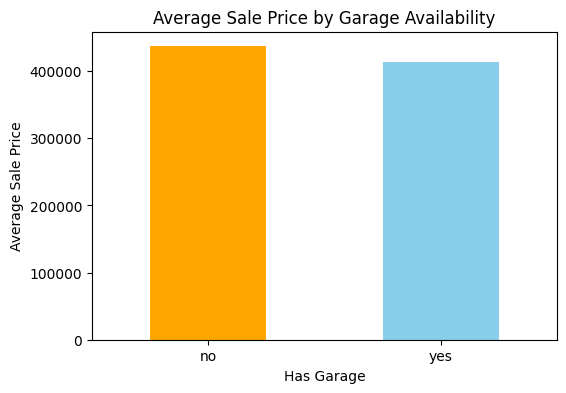

In [67]:
plt.figure(figsize=(6,4))
df.groupby('has_garage')['sale_price'].mean().plot(kind='bar', color=['orange', 'skyblue'])
plt.title('Average Sale Price by Garage Availability')
plt.xlabel('Has Garage')
plt.ylabel('Average Sale Price')
plt.xticks(rotation=0)
plt.show()

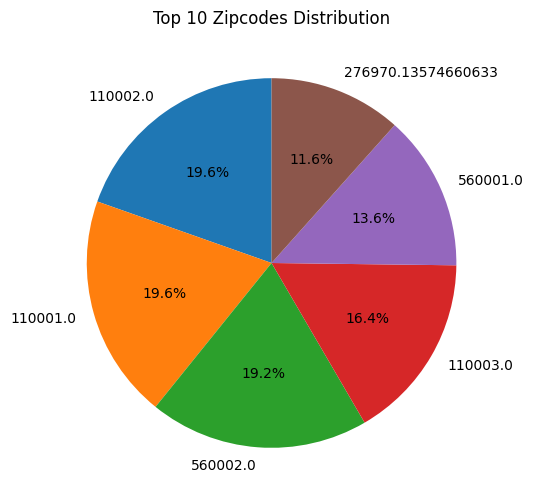

In [75]:
zipcode_counts = df['zipcode'].value_counts().head(10)
plt.figure(figsize=(6,6))
plt.pie(
    zipcode_counts,
    labels=zipcode_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Top 10 Zipcodes Distribution')
plt.show()

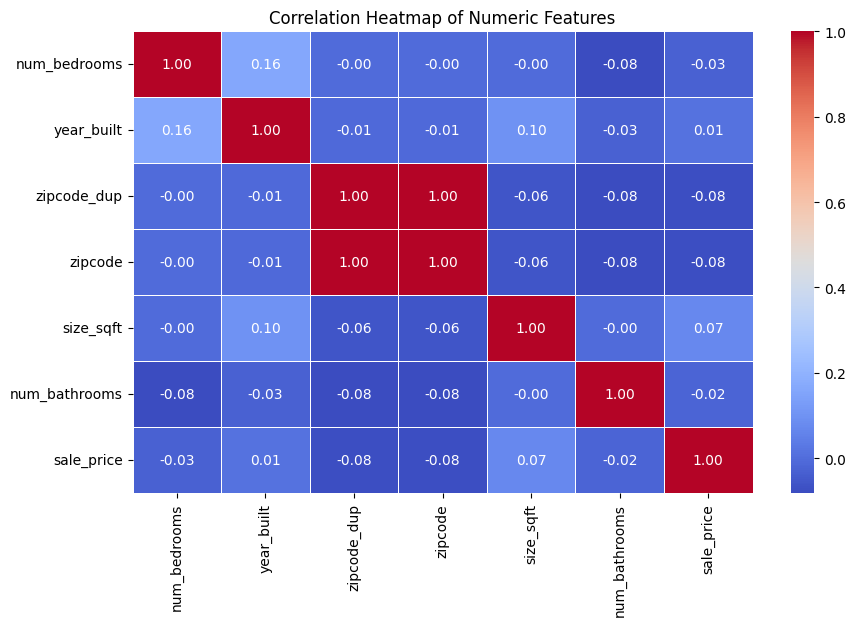

In [79]:
import seaborn as sns
df['size_sqft'] = pd.to_numeric(df['size_sqft'], errors='coerce')
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

1. Data Loading & Initial Inspection Loaded the housing_prices_regression.csv dataset using Pandas. Inspected column types and summary statistics.

Detected and removed duplicate rows to ensure unique observations for analysis.

2. Data Cleaning & Preparation Handled Missing Values:

Numeric columns (num_bedrooms, year_built, size_sqft, num_bathrooms, sale_price): Converted to numeric type. Filled missing values using suitable statistics:

Mean for continuous data (e.g., size, price, bedrooms).

Median for columns with potential outliers (e.g., year built).

Categorical columns (zipcode, zipcode_dup, has_garage, has_garden): Filled missing values with the mode (most frequent value).

id column: Standardized by replacing 'unknown' values with NA and filled with new unique IDs for missing entries.

Standardized Binary Columns:

Unified representations for binary columns (has_garage, has_garden):

Converted all case variants and abbreviations ('Yes', 'yes', 'ye', 'ys', etc.) to "yes"

All forms of "no" to "no"

Checked for Remaining Missing Values: Confirmed that missing values were filled, ensuring a complete dataset before analysis.

3. Data Exploration & Visualization Unique Value Analysis:

Reviewed unique values for all columns for data consistency and anomaly detection.

Visualizations Produced:

Bar Plot: Displayed average sale price grouped by number of bedrooms (num_bedrooms). Revealed how property size by bedroom count influences price.

Scatter Plot:

Examined sale price against year built to analyze temporal trends in home value.

Pie Chart:

Illustrated the frequency distribution of the top 10 zipcodes, highlighting location-based grouping in the dataset.

Correlation Heatmap:

Presented the pairwise correlations between major numeric variables (num_bedrooms, year_built, size_sqft, num_bathrooms, sale_price). This informed feature selection and model design by showing which variables are most closely linked.

4. Key Insights Price Variation by Bedrooms:

Bar plot indicated that homes with more bedrooms generally command higher prices, but with non-linear jumps that could be attributed to other features or market factors.

Year Built vs. Pricing:

Scatter plot showed both older and newer homes with high sale prices, suggesting year built alone isn't a simple predictor of price.

Zipcode Concentrations:

Pie chart identified specific zipcodes dominating the listings, which may suggest areas of higher market activity or data collection bias.

Feature Relationships:

The heatmap revealed that size (size_sqft) and number of bedrooms are highly correlated with sale price—key predictors for regression models.

5. Data Analysis Process Steps Read the dataset and preview info.

Drop duplicates.

Identify and fill missing values using appropriate methods.

Standardize categorical and binary columns.

Check and document unique values and data distribution.

Visualize important features via bar plots, scatterplots, pie charts, and heatmaps for exploratory data analysis.

6. Recommendations for Further Modeling Feature engineering: Consider creating additional features (e.g., age of property, price per sqft).

Outlier detection: Investigate unusually high or low sale prices for anomaly analysis.

Geographical analysis: Further geographic mapping for zipcodes could reveal market clusters.

Regression modeling: Use size, bedrooms, and location as major predictors for price modeling.

Categorical encoding: For non-numeric fields, properly encode for ML algorithms.